# Phân tích cảm xúc bình luận sản phẩm (3 lớp: Tích cực / Trung lập / Tiêu cực)

Huấn luyện mô hình phân loại cảm xúc tiếng Việt từ dữ liệu bình luận đã gán nhãn (`data - data.csv`), dùng cho tính năng đánh giá sản phẩm của đồ án ChuyenDeTN.

**Đầu ra**: `sentiment_model.joblib` (gồm `vectorizer` + `model`) để tích hợp vào Django ở `reviews/ml/sentiment.py`.

## 1. Import thư viện

In [1]:
import re
from pathlib import Path

import joblib
import pandas as pd
from underthesea import word_tokenize  # tách từ tiếng Việt (ghép từ ghép bằng "_")

from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

## 2. Đọc dữ liệu

File CSV gốc có cột `comment` (nội dung bình luận), `label` (nhãn `POS`/`NEU`/`NEG`), `rate` (số sao) và một cột rỗng thừa do export từ Google Sheets (mỗi dòng có dấu phẩy cuối). Chỉ cần `comment` và `label` cho bài toán phân loại cảm xúc.

In [2]:
DATA_PATH = Path("data - data.csv")

df = pd.read_csv(DATA_PATH)
df = df[["comment", "label"]].copy()

print("Số dòng ban đầu:", len(df))
print(df["label"].value_counts())
df.head()

Số dòng ban đầu: 31460
label
POS    20093
NEG     6669
NEU     4698
Name: count, dtype: int64


,comment,label
0,Áo bao đẹp ạ!!,POS
1,Tuyệt vời !,POS
2,2day ao khong giong trong.,NEG
3,"Mùi thơm,bôi lên da mềm da.",POS
4,"Vải đẹp, dày dặn.",POS


## 3. Làm sạch dữ liệu

- Bỏ dòng thiếu nội dung/nhãn.
- Chuẩn hóa khoảng trắng thừa và gộp dấu câu lặp lại nhiều lần (`"!!!"` → `"!"`) để giảm nhiễu khi tính TF-IDF - **giữ nguyên emoji** vì emoji mang tín hiệu cảm xúc khá rõ trong bình luận mua sắm (vd `😊`, `❤️`).
- **Bỏ bình luận trùng lặp**: dữ liệu gốc có nhiều câu giống hệt nhau (mẫu câu soạn sẵn của shop). Nếu không loại bỏ, cùng một câu có thể vừa nằm ở tập train vừa nằm ở tập test, khiến kết quả đánh giá bị ảo (data leakage) - đây là lỗi notebook mẫu ban đầu chưa xử lý.

In [3]:
def clean_text(text: str) -> str:
    """Chuẩn hóa cơ bản trước khi tách từ."""
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"([!?.,])\1+", r"\1", text)
    return text


df = df.dropna(subset=["comment", "label"]).copy()
df["comment"] = df["comment"].map(clean_text)
df = df[df["comment"].str.len() > 0]

before = len(df)
df = df.drop_duplicates(subset=["comment"]).reset_index(drop=True)
print(f"Đã bỏ {before - len(df)} bình luận trùng lặp, còn lại {len(df)} dòng.")

print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True).round(3))

Đã bỏ 4754 bình luận trùng lặp, còn lại 26706 dòng.
label
POS    16148
NEG     6315
NEU     4243
Name: count, dtype: int64
label
POS    0.605
NEG    0.236
NEU    0.159
Name: proportion, dtype: float64


## 4. Tiền xử lý — tách từ tiếng Việt (underthesea)

`word_tokenize(text, format="text")` ghép các từ ghép tiếng Việt bằng dấu `_` (vd `chất lượng` → `chất_lượng`), giúp TF-IDF hiểu đúng đơn vị từ thay vì tách rời từng âm tiết. **Bước này phải giống hệt lúc phục vụ dự đoán thật ở Django** (BƯỚC 5), nếu không vector hóa lúc dự đoán sẽ lệch với lúc train.

In [4]:
df["text_processed"] = df["comment"].map(lambda t: word_tokenize(t, format="text"))
df[["comment", "text_processed", "label"]].head(10)

,comment,text_processed,label
0,Áo bao đẹp ạ!,Áo bao đẹp ạ !,POS
1,Tuyệt vời !,Tuyệt_vời !,POS
2,2day ao khong giong trong.,2 day ao khong giong trong .,NEG
3,"Mùi thơm,bôi lên da mềm da.","Mùi thơm , bôi lên da mềm_da .",POS
4,"Vải đẹp, dày dặn.","Vải đẹp , dày_dặn .",POS
5,"Hàng rất đẹp, rất chi là ưng ý.","Hàng rất đẹp , rất chi là ưng_ý .",POS
6,"Chất lượng sản phẩm tốt, date dài.","Chất_lượng sản_phẩm tốt , date dài .",POS
7,Ăn nói và thái độ phục vụ tốt.,Ăn_nói và thái_độ phục_vụ tốt .,POS
8,Đóng gói sản phẩm chắc chắn.,Đóng_gói sản_phẩm chắc_chắn .,POS
9,tất sờn hết ca chưa dùng mà vay r.,tất_sờn hết ca chưa dùng mà vay r .,NEG


## 5. Chia tập train/test (80% / 20%, giữ tỉ lệ nhãn)

In [5]:
X = df["text_processed"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train:", len(X_train), "| Test:", len(X_test))
print(y_train.value_counts())

Train: 21364 | Test: 5342
label
POS    12918
NEG     5052
NEU     3394
Name: count, dtype: int64


## 6. Vector hóa TF-IDF

**KHÔNG** dùng `stop_words="english"` như notebook mẫu ban đầu - đó là danh sách từ dừng tiếng Anh, vô nghĩa với dữ liệu tiếng Việt. `ngram_range=(1, 2)` giữ lại cả cụm 2 từ (vd `"không đẹp"`) để mô hình phân biệt được phủ định.

In [6]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_features=30000,
    sublinear_tf=True,
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Số đặc trưng (từ/cụm từ):", len(vectorizer.vocabulary_))

Số đặc trưng (từ/cụm từ): 10181


## 7. Huấn luyện & so sánh nhiều mô hình

Dữ liệu mất cân bằng rõ (lớp `POS` chiếm đa số, `NEU` ít nhất) nên mọi mô hình đều dùng `class_weight="balanced"` để không thiên vị lớp đa số. So sánh bằng **macro-F1** (trung bình F1 của cả 3 lớp, coi trọng lớp thiểu số như nhau) thay vì accuracy, vì accuracy sẽ bị lớp `POS` áp đảo và che khuất việc mô hình dự đoán kém ở lớp `NEU` - đúng vấn đề mà bản kế hoạch trước đã ghi nhận (F1 lớp NEU thấp).

In [7]:
candidate_models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "ComplementNB": ComplementNB(),
    "LinearSVC (calibrated)": CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", random_state=RANDOM_STATE), cv=3
    ),
}

results = []
reports = {}

for name, clf in candidate_models.items():
    clf.fit(X_train_vec, y_train)
    y_pred = clf.predict(X_test_vec)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    results.append({"model": name, "macro_f1": macro_f1})
    reports[name] = classification_report(y_test, y_pred, digits=3)
    candidate_models[name] = clf  # giữ lại model đã fit

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
results_df

,model,macro_f1
0,LogisticRegression,0.647957
1,ComplementNB,0.626404
2,LinearSVC (calibrated),0.597879


### Báo cáo chi tiết từng mô hình (precision / recall / F1 theo từng lớp)

In [8]:
for name, report in reports.items():
    print(f"=== {name} ===")
    print(report)
    print("-" * 70)

=== LogisticRegression ===
              precision    recall  f1-score   support

         NEG      0.669     0.715     0.691      1263
         NEU      0.348     0.483     0.405       849
         POS      0.910     0.793     0.848      3230

    accuracy                          0.726      5342
   macro avg      0.643     0.664     0.648      5342
weighted avg      0.764     0.726     0.740      5342

----------------------------------------------------------------------
=== ComplementNB ===
              precision    recall  f1-score   support

         NEG      0.603     0.831     0.699      1263
         NEU      0.391     0.273     0.322       849
         POS      0.890     0.829     0.859      3230

    accuracy                          0.741      5342
   macro avg      0.628     0.644     0.626      5342
weighted avg      0.743     0.741     0.736      5342

----------------------------------------------------------------------
=== LinearSVC (calibrated) ===
              pre

## 8. Chọn mô hình tốt nhất & ma trận nhầm lẫn

Mô hình được chọn: LogisticRegression


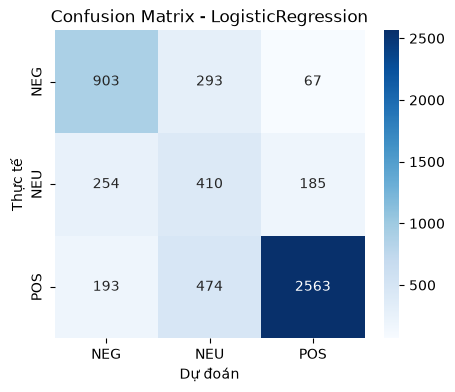

In [9]:
best_name = results_df.iloc[0]["model"]
best_model = candidate_models[best_name]
print("Mô hình được chọn:", best_name)

y_pred_best = best_model.predict(X_test_vec)
labels_order = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_best, labels=labels_order)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.title(f"Confusion Matrix - {best_name}")
plt.show()

## 9. Lưu mô hình

Lưu **cả `vectorizer` lẫn `model`** trong cùng một file `.joblib` (dạng dict) - lúc dự đoán ở Django cần dùng đúng `vectorizer` đã fit này để biến câu mới thành vector cùng không gian đặc trưng với lúc train, không thể tách rời hai thứ này.

In [10]:
MODEL_PATH = Path("sentiment_model.joblib")

joblib.dump({"vectorizer": vectorizer, "model": best_model}, MODEL_PATH)
print("Đã lưu:", MODEL_PATH.resolve())

Đã lưu: D:\DoAnTN\phantichcamxuc\sentiment_model.joblib


## 10. Hàm dự đoán dùng chung

Hàm này sẽ được chép gần như nguyên vẹn sang `reviews/ml/sentiment.py` ở BƯỚC 5 - viết ở đây trước để kiểm tra logic đúng ngay trong notebook.

In [11]:
def predict_sentiment(text: str):
    """Tiền xử lý GIỐNG HỆT lúc train rồi dự đoán nhãn cảm xúc.

    Trả về (nhãn, độ tin cậy) với độ tin cậy = xác suất lớn nhất trong 3 lớp.
    """
    processed = word_tokenize(clean_text(text), format="text")
    vector = vectorizer.transform([processed])
    proba = best_model.predict_proba(vector)[0]
    label = best_model.classes_[proba.argmax()]
    confidence = proba.max()
    return label, confidence


samples = [
    "Chất lượng sản phẩm tuyệt vời, giao hàng siêu nhanh, sẽ ủng hộ shop dài dài.",
    "Sản phẩm tạm ổn, không có gì đặc biệt, giao hàng đúng hẹn.",
    "Hàng kém chất lượng, giao sai mẫu, rất thất vọng.",
]

for text in samples:
    label, confidence = predict_sentiment(text)
    print(f"[{label} | {confidence:.2%}] {text}")

[POS | 98.50%] Chất lượng sản phẩm tuyệt vời, giao hàng siêu nhanh, sẽ ủng hộ shop dài dài.
[NEU | 58.39%] Sản phẩm tạm ổn, không có gì đặc biệt, giao hàng đúng hẹn.
[NEG | 97.80%] Hàng kém chất lượng, giao sai mẫu, rất thất vọng.
